# 物流销售综合分析

本 Notebook 使用 pandas 完成数据清洗与规整，使用 Matplotlib 进行可视化。原始数据位于 `E:/animal/data_wuliu.csv`，不会被覆盖。

In [18]:
# 导入处理文件路径的工具。
from pathlib import Path
# 导入 pandas，用来读取和整理表格数据。
import pandas as pd
# 导入正则表达式工具，用于识别金额单位。
import re
# 导入 Matplotlib，用来绘制分析图表。
import matplotlib.pyplot as plt
# 导入项目中复用的指标计算和图片保存函数。
from analysis import DEFAULT_SOURCE, make_kpis, save_figures
# 把 Notebook 当前目录作为结果输出目录。
OUTPUT_DIR = Path.cwd()
# 把生成的图片统一放入 figures 子文件夹。
FIGURE_DIR = OUTPUT_DIR / 'figures'
# 设置表格最多显示 30 列，避免重要字段被隐藏。
pd.set_option('display.max_columns', 30)
# 设置中文字体候选，减少图表中文乱码。
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
# 正常显示坐标轴中的负号。
plt.rcParams['axes.unicode_minus'] = False

## 1. 读取与数据质量概览

In [19]:
# 先读取原始数据，使用 GB18030 编码，并暂时全部按字符串处理。
raw = pd.read_csv(DEFAULT_SOURCE, encoding='gb18030', dtype='string')
# 查看原始数据规模、前几行、缺失情况和完全重复记录数量。
print(f'原始数据形状：{raw.shape}')
display(raw.head())
display(pd.DataFrame({'缺失数量': raw.isna().sum(), '缺失率': raw.isna().mean()}))
print(f'完全重复记录数：{raw.duplicated().sum()}')

原始数据形状：(1161, 10)


,订单号,订单行,销售时间,交货时间,货品交货状况,货品,货品用户反馈,销售区域,数量,销售金额
0,P096311,10,2016-7-30,2016-9-30,晚交货,货品3,质量合格,华北,2,"1052,75元"
1,P096826,10,2016-8-30,2016-10-30,按时交货,货品3,质量合格,华北,10,"11,50万元"
2,<NA>,20,2016-8-30,2016-10-30,按时交货,货品3,质量合格,华北,10,"11,50万元"
3,P097435,10,2016-7-30,2016-9-30,按时交货,货品1,返修,华南,2,"6858,77元"
4,P097446,60,2016-11-26,2017-1-26,晚交货,货品3,质量合格,华北,15,"129,58元"


,缺失数量,缺失率
订单号,2,0.001723
订单行,0,0.000000
销售时间,0,0.000000
交货时间,0,0.000000
货品交货状况,2,0.001723
货品,0,0.000000
货品用户反馈,0,0.000000
销售区域,0,0.000000
数量,4,0.003445
销售金额,0,0.000000


完全重复记录数：9


## 2. 清洗与字段规整

In [20]:
# 复制原始表格，后续清洗只修改副本，不影响 raw。
data = raw.copy()
# 记录删除重复行前的行数，便于准确统计删除数量。
before_duplicates = len(data)
# 删除完全重复的行，保留每组重复数据的第一行。
data.drop_duplicates(keep='first', inplace=True)
# 计算实际删除的完全重复行数量。
duplicate_rows_removed = before_duplicates - len(data)
# 删除任意字段包含空值的行，保证后续分析使用完整记录。
data.dropna(axis=0, how='any', inplace=True)
# 删除不参与本次分析的订单行列。
data.drop('订单行', axis=1, inplace=True)
# 删除行后重新生成从 0 开始的连续索引。
data.reset_index(drop=True, inplace=True)
# 定义金额转换函数，把带单位的文字金额转换为人民币元。
def convert_amount(value):
    # 把输入转成字符串并去除两端空格。
    text = str(value).strip().replace(' ', '')
    # 识别数字、小数逗号和“元/万元”单位。
    match = re.fullmatch(r'([0-9]+(?:,[0-9]+)?)\s*(元|万元)', text)
    # 无法识别的金额返回缺失值，后面会被删除。
    if not match:
        return float('nan')
    # 逗号改成小数点；万元需要换算成元。
    number = float(match.group(1).replace(',', '.'))
    # 根据单位返回统一的人民币元金额。
    return number * 10000 if match.group(2) == '万元' else number
# 用 map 逐个转换“销售金额”列中的每一个元素。
data['销售金额'] = data['销售金额'].map(convert_amount)
# 删除金额转换失败后新产生的空值。
data.dropna(axis=0, how='any', inplace=True)
# 转换后再次整理索引，保证行号连续。
data.reset_index(drop=True, inplace=True)
# 将“销售时间”列转换为标准的日期时间格式。
data['销售时间'] = pd.to_datetime(data['销售时间'])
# 对每条销售时间应用 lambda 表达式，提取月份数值并创建“月份”列。
data['月份'] = data['销售时间'].apply(lambda x: x.month)
# 将中文列名改成程序统一使用的英文列名，并保留新建的“月份”列。
df = data.rename(columns={'订单号': 'order_id', '销售时间': 'sale_date', '交货时间': 'delivery_date', '货品交货状况': 'delivery_status', '货品': 'product', '货品用户反馈': 'customer_feedback', '销售区域': 'sales_region', '数量': 'quantity', '销售金额': 'sales_amount_cny'}).copy()
# 将销售数量转换为数值类型；无法转换的内容会变成空值。
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
# 再次确保销售金额为数值类型，供均值、标准差等统计计算使用。
df['sales_amount_cny'] = pd.to_numeric(df['sales_amount_cny'], errors='coerce')
# 删除数值转换失败产生的空值，避免后续统计结果受到影响。
df.dropna(subset=['quantity', 'sales_amount_cny'], inplace=True)
# 删除记录后重新生成连续索引。
df.reset_index(drop=True, inplace=True)
# 把销售日期和交货日期转换成日期类型。
df['sale_date'] = pd.to_datetime(df['sale_date'])
# 计算每条记录从销售到交货经过了多少天。
df['delivery_days'] = (pd.to_datetime(df['delivery_date']) - df['sale_date']).dt.days
# 按交货状态判断是否按时交货。
df['is_on_time'] = df['delivery_status'].eq('按时交货').astype('boolean')
# 因为前面已删除异常行，这里把保留下来的记录标记为正常。
df['data_quality_flag'] = '正常'
# 保存清洗前后的数量摘要，供后续展示和导出。
quality = {'raw_rows': len(raw), 'clean_rows': len(df), 'duplicate_rows_removed': duplicate_rows_removed, 'clean_missing': df.isna().sum().to_dict()}
# 查看清洗后的规模、示例、字段类型、缺失值和质量标签。
print(f'清洗后数据形状：{df.shape}')
display(df.head())
display(df.dtypes.to_frame('数据类型'))
display(pd.DataFrame({'缺失数量': df.isna().sum()}))
display(df['data_quality_flag'].value_counts().to_frame('记录数'))

清洗后数据形状：(1146, 13)


,order_id,sale_date,delivery_date,delivery_status,product,customer_feedback,sales_region,quantity,sales_amount_cny,月份,delivery_days,is_on_time,data_quality_flag
0,P096311,2016-07-30,2016-9-30,晚交货,货品3,质量合格,华北,2.0,1052.75,7,62,False,正常
1,P096826,2016-08-30,2016-10-30,按时交货,货品3,质量合格,华北,10.0,115000.00,8,61,True,正常
2,P097435,2016-07-30,2016-9-30,按时交货,货品1,返修,华南,2.0,6858.77,7,62,True,正常
3,P097446,2016-11-26,2017-1-26,晚交货,货品3,质量合格,华北,15.0,129.58,11,61,False,正常
4,P097446,2016-11-26,2017-1-26,晚交货,货品3,拒货,华北,15.0,32.39,11,61,False,正常


,数据类型
order_id,string
sale_date,datetime64[us]
delivery_date,string
delivery_status,string
product,string
customer_feedback,string
sales_region,string
quantity,Float64
sales_amount_cny,float64
月份,int64


,缺失数量
order_id,0
sale_date,0
delivery_date,0
delivery_status,0
product,0
customer_feedback,0
sales_region,0
quantity,0
sales_amount_cny,0
月份,0


,记录数
data_quality_flag,
正常,1146


## 3. 核心指标

In [21]:
# 根据清洗后的明细数据计算订单数、金额、数量和交付等核心指标。
# 计算清洗后的核心业务指标。
# 根据清洗结果计算核心指标。
kpis = make_kpis(df)
# 将指标转换为表格后显示。
display(kpis.to_frame('指标值'))
# 输出删除的完全重复行数量。
print(f"删除重复记录：{quality['duplicate_rows_removed']} 条")
# 输出按时交货率，未知状态不参与计算。
print(f"按时交货率（未知状态不计入）：{kpis['按时交货率']:.2%}")

,指标值
清洗后记录数,1.146000e+03
订单数,8.650000e+02
销售数量合计,8.717550e+04
销售金额合计（元）,1.402118e+06
平均交货天数,7.560646e+01
按时交货率,1.919721e-02


删除重复记录：9 条
按时交货率（未知状态不计入）：1.92%


## 4. 异常值识别

本节不删除异常值，只按以下规则识别并报告：销售金额最小值为 0；销售数量或销售金额的标准差超过均值的 8 倍，且均值大于中位数。

In [22]:
# 选择需要检查异常情况的销售数量和销售金额两列。
outlier_columns = ['quantity', 'sales_amount_cny']
# 计算每列的最小值、均值、中位数和标准差。
outlier_summary = df[outlier_columns].agg(['min', 'mean', 'median', 'std']).T
# 判断销售金额最小值是否为 0。
amount_min_is_zero = outlier_summary.loc['sales_amount_cny', 'min'] == 0
# 判断每列的标准差是否超过均值的 8 倍。
outlier_summary['标准差超过均值8倍'] = outlier_summary['std'] > outlier_summary['mean'] * 8
# 判断每列的均值是否大于中位数。
outlier_summary['均值大于中位数'] = outlier_summary['mean'] > outlier_summary['median']
# 两个条件同时满足时，标记为“标准差过大”异常。
outlier_summary['标准差过大异常'] = outlier_summary['标准差超过均值8倍'] & outlier_summary['均值大于中位数']
# 将标准字段名替换为更易读的中文名称。
outlier_summary.index = ['销售数量', '销售金额（元）']
# 显示异常值识别所依据的统计量和判断结果。
display(outlier_summary)
# 输出销售金额最小值异常的结论。
print(f'销售金额最小值：{outlier_summary.loc["销售金额（元）", "min"]}')
# 根据最小值是否为 0 输出对应的判断。
print(f'最小值异常（销售金额为 0）：{amount_min_is_zero}')
# 输出销售数量的标准差异常判断。
print(f'销售数量标准差过大异常：{outlier_summary.loc["销售数量", "标准差过大异常"]}')
# 输出销售金额的标准差异常判断。
print(f'销售金额标准差过大异常：{outlier_summary.loc["销售金额（元）", "标准差过大异常"]}')

,min,mean,median,std,标准差超过均值8倍,均值大于中位数,标准差过大异常
销售数量,1.0,76.069372,1.000,589.416486,False,True,False
销售金额（元）,0.0,1223.488255,94.765,11145.993359,True,True,True


销售金额最小值：0.0
最小值异常（销售金额为 0）：True
销售数量标准差过大异常：False
销售金额标准差过大异常：True


## 5. 月度趋势

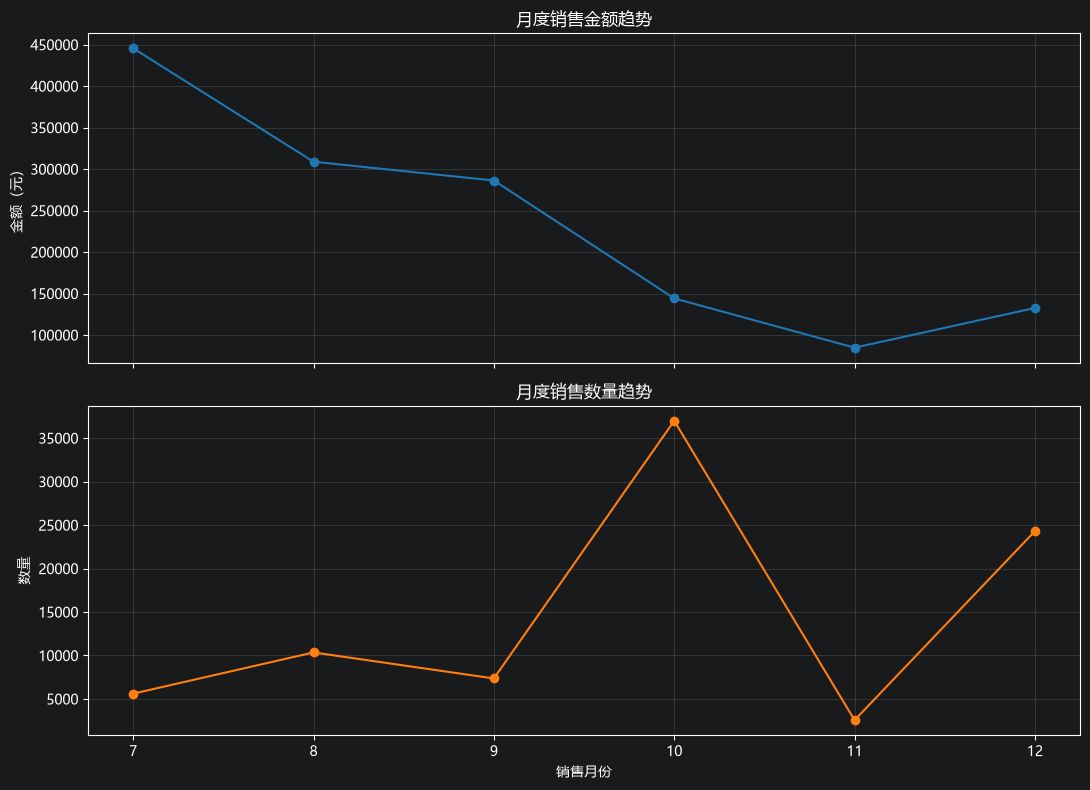

In [23]:
# 按销售月份汇总金额和数量，用于观察业务随时间的变化趋势。
# 按销售月份分组，并汇总每个月的销售金额和数量。
# 按新建的“月份”列分组，汇总每月金额和数量。
monthly = df.groupby('月份', observed=True).agg(
    # 汇总月度销售金额和销售数量。
    sales_amount_cny=('sales_amount_cny', 'sum'), quantity=('quantity', 'sum')
)
# 上图看销售金额，下图看销售数量；共享横轴便于按月份对照。
# 创建上下排列的两个图表。
# 创建上下排列的两个图表。
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
# 在上方图表绘制月度销售金额。
monthly['sales_amount_cny'].plot(ax=axes[0], marker='o', color='#1f77b4', title='月度销售金额趋势')
# 在下方图表绘制月度销售数量。
monthly['quantity'].plot(ax=axes[1], marker='o', color='#ff7f0e', title='月度销售数量趋势')
# 设置坐标轴名称。
axes[0].set_ylabel('金额（元）'); axes[1].set_ylabel('数量'); axes[1].set_xlabel('销售月份')
# 添加浅色网格线，方便比较数据。
for ax in axes: ax.grid(alpha=.25)
# 调整布局并显示图表。
plt.tight_layout(); plt.show()

## 5. 区域与货品分析

In [24]:
# 分别按销售区域和货品汇总金额、数量及交付表现，并按金额降序排列。
# 按销售区域汇总销售金额、数量和交付表现。
region_summary = df.groupby('sales_region', dropna=False, observed=True).agg(
    # 汇总区域销售金额和数量。
    销售金额=('sales_amount_cny', 'sum'), 销售数量=('quantity', 'sum'),
    # 计算区域平均交货天数和按时交货率。
    平均交货天数=('delivery_days', 'mean'), 按时交货率=('is_on_time', 'mean')
).sort_values('销售金额', ascending=False)
# 按货品汇总销售金额和销售数量。
product_summary = df.groupby('product', dropna=False, observed=True).agg(
    # 汇总每种货品的销售金额和销售数量。
    销售金额=('sales_amount_cny', 'sum'), 销售数量=('quantity', 'sum')
).sort_values('销售金额', ascending=False)
# 显示区域和货品汇总结果。
display(region_summary); display(product_summary)

,销售金额,销售数量,平均交货天数,按时交货率
sales_region,,,,
华北,634322.75,11900.5,76.924901,0.011858
华东,293196.29,53812.0,78.811688,0.003247
华南,245527.74,579.0,69.272727,0.727273
西北,127066.15,5240.0,70.491803,0.016393
马来西亚,71639.35,9911.0,74.187117,0.018405
泰国,30365.26,5733.0,73.058824,0.016043


,销售金额,销售数量
product,,
货品3,520546.32,9073.5
货品1,462150.58,3417.0
货品2,305366.79,55322.0
货品6,59468.85,8401.0
货品5,30365.26,5733.0
货品4,24219.74,5229.0


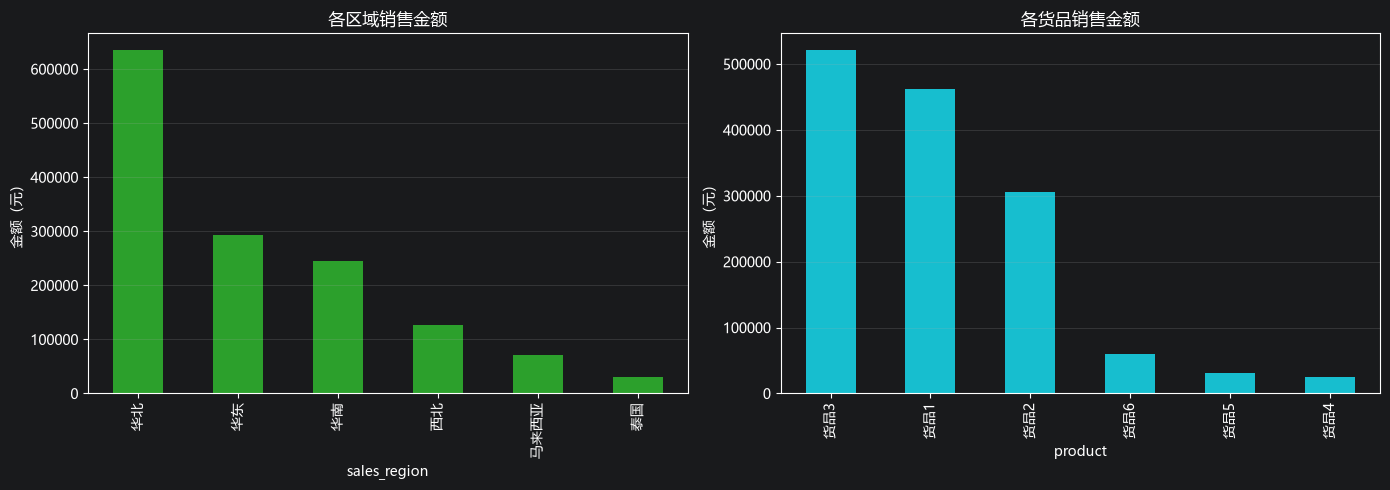

In [25]:
# 用两个柱状图比较不同区域和不同货品的销售金额贡献。
# 创建左右并排的两个图表区域。
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
region_summary['销售金额'].plot(kind='bar', ax=axes[0], color='#2ca02c', title='各区域销售金额')
product_summary['销售金额'].plot(kind='bar', ax=axes[1], color='#17becf', title='各货品销售金额')
for ax in axes: ax.set_ylabel('金额（元）'); ax.grid(axis='y', alpha=.25)
plt.tight_layout(); plt.show()

## 6. 交付与用户反馈

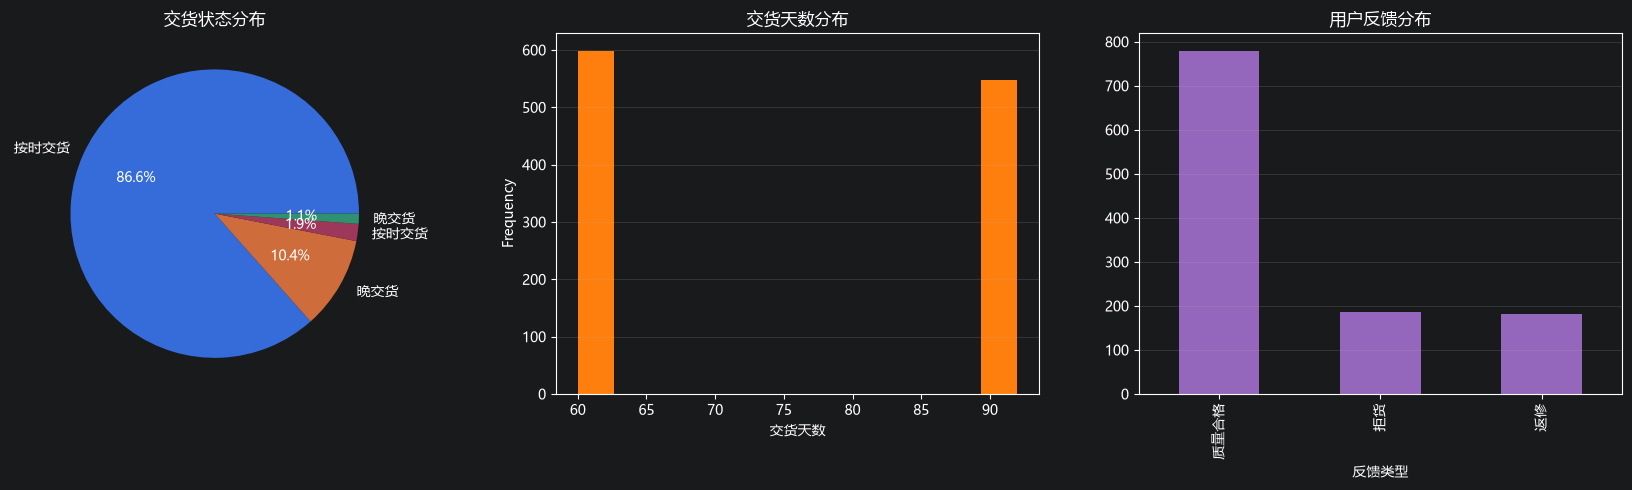

In [26]:
# 同时查看交货状态占比、交货天数分布和用户反馈类别。
# 创建三个并排图表，观察交货和反馈情况。
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
df['delivery_status'].value_counts().plot(kind='pie', autopct='%.1f%%', ax=axes[0], title='交货状态分布')
axes[0].set_ylabel('')
df['delivery_days'].dropna().plot(kind='hist', bins=12, ax=axes[1], color='#ff7f0e', title='交货天数分布')
df['customer_feedback'].value_counts().plot(kind='bar', ax=axes[2], color='#9467bd', title='用户反馈分布')
axes[1].set_xlabel('交货天数'); axes[2].set_xlabel('反馈类型')
for ax in axes[1:]: ax.grid(axis='y', alpha=.25)
plt.tight_layout(); plt.show()

## 7. 输出结果

In [27]:
# 将清洗明细、核心指标、缺失值质量报告和分析图表保存到项目目录。
# 保存清洗后的明细数据。
df.to_csv(OUTPUT_DIR / 'data_wuliu_cleaned.csv', index=False, encoding='utf-8-sig')
kpis.rename('value').to_csv(OUTPUT_DIR / 'kpis.csv', encoding='utf-8-sig')
pd.DataFrame({'metric': list(quality['clean_missing']), 'missing_count': list(quality['clean_missing'].values())}).to_csv(OUTPUT_DIR / 'quality_report.csv', index=False, encoding='utf-8-sig')
# 打印实际生成的图片路径，方便在文件夹中找到结果。
saved = save_figures(df, FIGURE_DIR)
print('已输出清洗数据、指标、质量报告和图表：')
for path in saved: print(path)

PermissionError: [Errno 13] Permission denied: 'E:\\文档\\python_learn\\python-2\\data_wuliu_cleaned.csv'